In [32]:
import pygimli as pg 
import matplotlib.pyplot as plt
import numpy as np
from pygimli.physics import ert
import pygimli.meshtools as mt
from scipy.interpolate import griddata, Rbf
from skimage.metrics import structural_similarity as ssim
from skimage.restoration import inpaint
import pandas as pd
import os
output_dir="l1_sm_log_interplinear"
os.makedirs(output_dir, exist_ok=True)

03/04/26 - 20:28:33 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 


Data: Sensors: 21 data: 171, nonzero entries: ['a', 'b', 'k', 'm', 'n', 'valid']
relativeError set to a value > 0.5 .. assuming this is a percentage Error level dividing them by 100


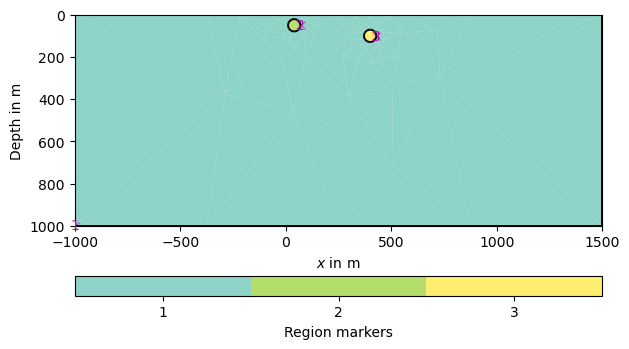

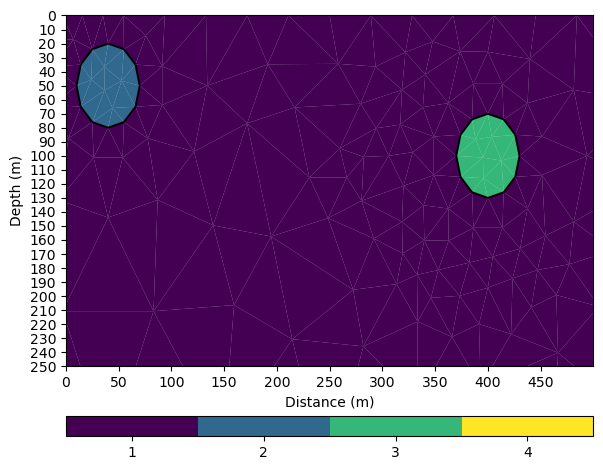

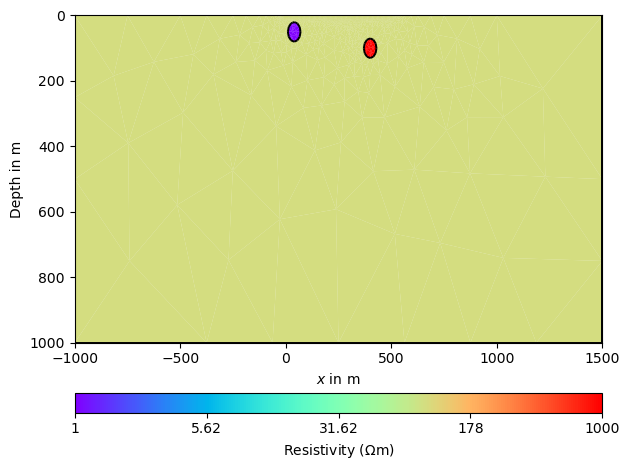

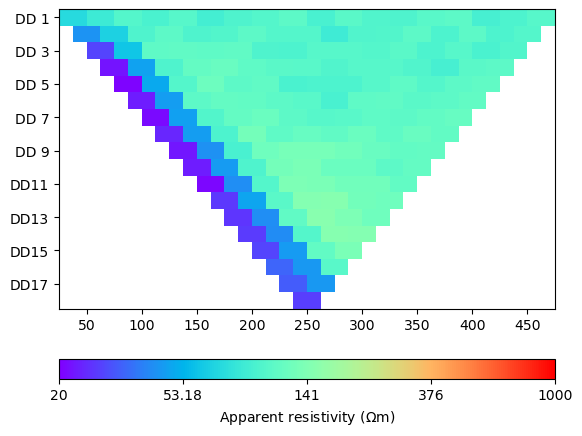

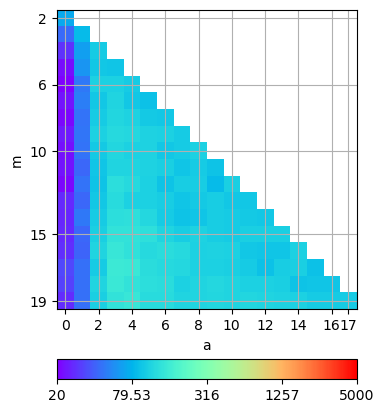

In [33]:
world=mt.createWorld(start=[-1000,0],end=[1500,-1000],worldMarker=1)

body1=mt.createCircle(pos=[40,-50],radius=30,marker=2)
body2=mt.createCircle(pos=[400,-100],radius=30,marker=3)
geom=world+body1+body2

pg.show(geom,showMesh=True,quality=34)

mesh_cut = mt.createMesh(geom, quality=34)

x_min,x_max= 0,500
y_min,y_max= -250,0

ax, cbar = pg.show(mesh_cut, data=mesh_cut.cellMarkers(), 
                   showMesh=False, aspect='auto', 
                   cmap=plt.get_cmap("viridis", 4), cbar=True)
cbar.mappable.set_clim(0.5, 4.5)
cbar.set_ticks([1, 2, 3, 4])

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_yticks(np.arange(y_min, 1, 10)) 
ax.set_xticks(np.arange(x_min, x_max, 50)) 
ax.set_xlabel("Distance (m)")   
ax.set_ylabel("Depth (m)")

plt.draw()

spacing=25
scheme=ert.createData(
    elecs=np.linspace(start=0,stop=500,num=len(np.arange(0,501,spacing)))
    , schemeName='dd'
)
print(scheme)
for p in scheme.sensors():
    geom.createNode(p)
    geom.createNode(p-[0,0.1]) # create 2  nodes for FTDT
mesh_fwr=mt.createMesh(geom,quality=34)
rhomap=[[1,100],
        [2,1],
        [3,1000]]
pg.show(mesh_fwr,data=rhomap,label=pg.unit('res'), cMap='rainbow',logScale=True,aspect='auto')


data=ert.simulate(mesh_fwr,scheme=scheme, res=rhomap, noiseLevel=5, noiseAbs=1e-6, seed=1337)

pg.info(np.linalg.norm(data['err']),np.linalg.norm(data['rhoa']))
pg.info('Simulated data: ',data)
pg.info('The data contains : ',data.dataMap().keys())
pg.info('Sim rhoa (min/max) : ' ,min(data['rhoa']), max(data['rhoa']))
pg.info('Selected data noise % (min/ma)x : ', min(data['err'])*100, max(data['err'])*100)

data.remove(data['rhoa']<0)
pg.info('filtered rhoa minmax dd : ', min(data['rhoa']), max(data['rhoa']))

os.makedirs(output_dir, exist_ok=True) #Make new dir to save files

data.save(os.path.join(output_dir, f'{output_dir}_dd.dat'))

ert.show(data,cMap='rainbow',cMin=20,cMax=1000,logScale=True,title='DD')   #pseudosection
pg.viewer.mpl.showDataContainerAsMatrix(data,'a','m', 'rhoa',cMap='rainbow',cMin=20,cMax=5000,logScale=True,title='DD')

np.save(os.path.join(output_dir, f'{output_dir}_abmn_dd.npy'), np.column_stack([data['a'], data['b'], data['m'], data['n']]))
np.save(os.path.join(output_dir, f'{output_dir}_res_all_dd.npy'), np.column_stack([data['rhoa']]))
abmn_data_dd = np.load(os.path.join(output_dir, f'{output_dir}_abmn_dd.npy'))
res_data_dd=np.load(os.path.join(output_dir, f'{output_dir}_res_all_dd.npy'))

In [34]:
#timelapse, change body1 resistivity
new_vals=[1]

os.makedirs(f'{output_dir}/logs', exist_ok=True) #Make logs dir to save log files
os.makedirs(f'{output_dir}/timelapse', exist_ok=True) #Make timelapse dir to save data files
os.makedirs(f'{output_dir}/res_all_t', exist_ok=True) #Make res_all_t dir to save resistivity data files

for i, rho_val in enumerate(new_vals):
    rhomap[1][1]=rho_val
    data=ert.simulate(mesh_fwr,scheme=scheme, res=rhomap, noiseLevel=0.01, noiseAbs=1e-6, seed=1337)
    data.remove(data['rhoa']<0)


    filename=f'{output_dir}/timelapse/timelapse_{i}.dat'
    print(f'Value for marker 6: {new_vals[i]} Ohm.m, data saved to {filename}')
    with open(f'{output_dir}/logs/log_{i}.txt', 'w') as f:
        print(f"Step {i} | Marker6: {rho_val} ", file=f)
        print(f"Norm Err: {np.linalg.norm(data['err'])}", file=f)
        print(f"Min/Max Rhoa: {min(data['rhoa'])} / {max(data['rhoa'])}", file=f)
        print(f"Data: {data}", file=f)
    print(f'Log_{i}.txt created with details of Step {i}')
    data.save(filename)
    print(f'Done Step {i}')

    np.save(f'{output_dir}/res_all_t/res_all_t_{i}.npy', np.column_stack([data['rhoa']])) #Resistivity changes, keep inside the loop


np.save(f'{output_dir}/res_all_t/abmn.npy', np.column_stack([data['a'], data['b'], data['m'], data['n']])) #Geometry doesn't change.


Value for marker 6: 1 Ohm.m, data saved to l1_sm_log_interplinear/timelapse/timelapse_0.dat
Log_0.txt created with details of Step 0
Done Step 0


In [35]:
def fill_nan(image):
    image=image.copy()
    nan_mask = np.isnan(image)
    mean_value = np.nanmean(image)
    image[nan_mask] = mean_value
    return image, nan_mask

def compress(image, n_pixels, z_factor,rank): 
    image, nan_mask = fill_nan(image)
    U, S, Vt = np.linalg.svd(image, full_matrices=False)
    rank=len(S) if rank is None else rank
    U_reduced = U[:, :rank]
    S_reduced = S[:rank]
    Vt_reduced = Vt[:rank, :]
    compressed_image = np.dot(U_reduced, np.dot(np.diag(S_reduced), Vt_reduced))
    contributions = np.abs(U_reduced)  @ np.diag(S_reduced) @ np.abs(Vt_reduced)
    
    rows, cols = np.indices(image.shape)    
    pseudo_depth = np.abs(cols - rows).astype(float)

    if np.max(pseudo_depth) > 0:
        pseudo_depth /= np.max(pseudo_depth)

    depth_weight = 1 + z_factor * pseudo_depth
    contributions *= depth_weight

    contributions[nan_mask] = -np.inf

    #anchor points
    #first column (idx= 0)
    valid_rows_0 = np.flatnonzero(~nan_mask[:, 0])
    if valid_rows_0.size > 0:
        rows_min, rows_max, rows_mean = valid_rows_0[0], valid_rows_0[-1],valid_rows_0[valid_rows_0.size // 2]
        contributions[rows_min, 0],contributions[rows_max, 0], contributions[rows_mean, 0] = np.inf, np.inf, np.inf
    
    #set last column first row contribution to inf
    valid_cols= np.where(~nan_mask)[1]
    if valid_cols.size > 0:
        col_last = valid_cols.max()
        valid_rows_in_last_col = np.flatnonzero(~nan_mask[:, col_last])
        if valid_rows_in_last_col.size > 0:
            row_last = valid_rows_in_last_col[0]
            contributions[row_last, col_last] = np.inf

        unique_cols = np.unique(valid_cols)
        col_mean = unique_cols[unique_cols.size // 2]
        valid_rows_in_mean_col = np.flatnonzero(~nan_mask[:, col_mean])
        if valid_rows_in_mean_col.size > 0:
            contributions[valid_rows_in_mean_col[-1], col_mean] = np.inf

    flat_indices = np.argsort(contributions.flatten())[::-1][:n_pixels]
    significant_indices = np.unravel_index(flat_indices, image.shape)
    return compressed_image, significant_indices, nan_mask, contributions,rank

# def reconstruct(image_shape, significant_indices, pixel_values):
#     # Create an empty image with the given shape
#     compressed_image = np.full(image_shape, np.nan)
#     # Assign the provided pixel values to the significant indices
#     compressed_image[significant_indices] = pixel_values
#     # Interpolate to fill in the missing values
#     x, y = np.meshgrid(np.arange(image_shape[1]), np.arange(image_shape[0]))
#     mask = ~np.isnan(compressed_image)
#     x_known, y_known = x[mask], y[mask]
#     values_known = compressed_image[mask]
#     rbf_interpolator = Rbf(x_known, y_known, values_known, function='thin_plate')
#     interpolated_image =rbf_interpolator(x, y)
#     return interpolated_image

def reconstruct(image_shape, significant_indices, pixel_values):

    compressed_image = np.full(image_shape, np.nan)
    compressed_image[significant_indices] = pixel_values
    x, y = np.meshgrid(np.arange(image_shape[1]), np.arange(image_shape[0]))
    mask = ~np.isnan(compressed_image)
    interpolated_image = griddata(
        (x[mask], y[mask]),  # Points with known values
        compressed_image[mask],  # Known values
        (x, y),  # Points to interpolate
        method='linear'  # Interpolation 
        )
    return interpolated_image

# def reconstruct(image_shape, significant_indices, pixel_values):
#     #image inpainting 
#     compressed_image = np.full(image_shape, np.nan)
#     compressed_image[significant_indices] = pixel_values
#     mask = np.isnan(compressed_image)
#     interpolated_image = inpaint.inpaint_biharmonic(compressed_image, mask)
#     return interpolated_image



def plot_ert_checkerboard(data,plot=0):
    #Extract unique electrode positions
    electrodes = np.unique(data[['A', 'B', 'M', 'N']].values)
    electrode_map = {electrode: idx for idx, electrode in enumerate(sorted(electrodes))}
    #Create a grid
    grid_size = len(electrode_map)
    heatmap = np.full((grid_size, grid_size), np.nan)
    #Map values to the grid
    for _, row in data.iterrows():
        x = electrode_map[row['A']]
        y = electrode_map[row['M']]
        heatmap[y, x] = row['Res']
    if plot==1:
        #Plot the checkerboard heatmap
        plt.figure(figsize=(10, 8))
        plt.imshow(np.log10(heatmap), cmap='gist_rainbow', interpolation='nearest')
        plt.colorbar(label='ERT Measurement Value')
        plt.xticks(ticks=np.arange(grid_size), labels=sorted(electrode_map.keys()), rotation=90)
        plt.yticks(ticks=np.arange(grid_size), labels=sorted(electrode_map.keys()))
        plt.xlabel('Electrode A')
        plt.ylabel('Electrode N')
        plt.title('ERT Checkerboard Heatmap')
        plt.savefig(os.path.join(output_dir, f'{output_dir}_checkerboard_heatmap.png'))
        plt.close()
    return heatmap

In [36]:
abmn=np.load(f'{output_dir}/res_all_t/abmn.npy')
#create the first dataframe for electrode mapping
res_all_0 = np.load(f'{output_dir}/res_all_t/res_all_t_0.npy')
data_all_0 = np.column_stack([abmn, res_all_0[:,0]])
data = pd.DataFrame(data_all_0, columns=['A','B','M','N','Res'])

electrodes = np.unique(data[['A', 'B', 'M', 'N']].values)
electrode_map = {electrode: idx for idx, electrode in enumerate(sorted(electrodes))}
image=plot_ert_checkerboard(data,plot=1)


In [37]:

import logging
os.makedirs(f'{output_dir}/contributions', exist_ok=True) #Make contributions dir to save contribution maps

pg_logger = logging.getLogger('pyGIMLi')
pg_logger.setLevel(logging.WARNING)

all_images = []          
all_significant_indices = [] 
all_reconstructed_images = []
all_best_z = []
all_n_pixels = []           
all_ssim = []             
all_inv1, all_inv2 = [], []
all_chi2_1, all_chi2_2 = [], []

# optimize for z_factor 
z_range = np.arange(0.0, 0.4, 0.1)

for i in range(len(new_vals)):
    res_all = np.load(f'{output_dir}/res_all_t/res_all_t_{i}.npy')
    data_all = np.column_stack([abmn, res_all[:, 0]])
    data = pd.DataFrame(data_all, columns=['A', 'B', 'M', 'N', 'Res'])
    image = plot_ert_checkerboard(data, plot=0) 

    # Original Data Inversion
    filepath=f'{output_dir}/timelapse/timelapse_{i}.dat'
    datafile=pg.load(filepath)
    mgr1 = ert.ERTManager(datafile)
   

    inv1 = mgr1.invert(lam=20, verbose=False, robustData=True,blockyModel=True, paraMaxCellSize=30, paraDepth=140)
    chi2_1 = mgr1.inv.chi2()
    inv1_array = np.asarray(inv1) 

     # SSIM NEED MAPPING ############################################################
    x_centers=np.array([c.center()[0] for c in mgr1.paraDomain.cells()])
    y_centers=np.array([c.center()[1] for c in mgr1.paraDomain.cells()])
    grid_x, grid_y = np.meshgrid(np.linspace(0, 500, 100), np.linspace(-140, 0, 50))
    ################################################################################
    # MAP INV1 TO A GRID FOR COMPARISON WITH RECONSTRUCTED IMAGES###########################
    grid_inv1=griddata((x_centers,y_centers), inv1_array, (grid_x, grid_y), method='linear')
    grid_inv1[np.isnan(grid_inv1)] = np.nanmean(grid_inv1)  # Fill NaNs with mean for SSIM calculation
    data_range=grid_inv1.max() - grid_inv1.min()
    ######################################################################################### 

    #rmse for depth>5m
    cell_depths=[]
    all_cels=mgr1.paraDomain.cells()
    for cell in all_cels:
        depth=cell.center()[1]
        cell_depths.append(depth)
    cell_depths=np.array(cell_depths)
    mask_depth=cell_depths<-5
    
    valid_mask = ~np.isnan(image)
    original_valid_pixels = image[valid_mask]
    n_pixels = original_valid_pixels.size

    #decreasing num of pixels
    for n in range(n_pixels, n_pixels//5, -n_pixels//10): 
        
        # initialize params 
        max_ssim = -1 #ssim is the bigger the better, so we start with -1
        best_z = None
        best_significant_indices = None
        best_nan_mask = None
        best_reconstructed_images = None
        best_inv2_array = None
        best_chi2_2 = None
        
        # BYPASS COMPRESSION FOR THE FIRST ITERATION (ALL PIXELS) TO GET A BASELINE MODEL
        if n == n_pixels:
            best_z = 0.0
            max_ssim = 1.0
            best_inv2_array = inv1_array
            best_chi2_2 = chi2_1
            best_nan_mask = np.isnan(image)
            best_reconstructed_images = image.copy()
            best_significant_indices = np.where(~np.isnan(image))
            contributions_step = np.ones_like(image)  # Placeholder for baseline contribution
            np.save(f'{output_dir}/contributions/contributions_step{i}_n{int(n):03d}_z{best_z:.2f}.npy', contributions_step)
            
        else:
            #find best z for n 
            for z_test in z_range:
                #try log scaling
                image_log=np.log10(image.copy())
                compressed_image_log, significant_indices, nan_mask, contributions, _ = compress(image_log, n, z_factor=z_test, rank=None)
                contributions_step = contributions.copy()
                np.save(f'{output_dir}/contributions/contributions_step{i}_n{int(n):03d}_z{z_test:.2f}.npy',contributions_step)
                pixel_values_log = compressed_image_log[significant_indices]
                reconstructed_compressed_image_log = reconstruct(image_log.shape, significant_indices, pixel_values_log)   
                reconstructed_compressed_image=10**reconstructed_compressed_image_log    
                
                #map again 
                new_rhoa = []
                for _, row in data.iterrows():
                    x = electrode_map[row['A']]
                    y = electrode_map[row['M']]
                    new_rhoa.append(reconstructed_compressed_image[y, x])
                
                data_for_svd = pg.load(filepath)
                if len(data_for_svd['rhoa']) == len(new_rhoa):
                    data_for_svd['rhoa'] = np.array(new_rhoa)
                    rhoa_vals = np.array(data_for_svd['rhoa'])
                    mask_inv = np.isnan(rhoa_vals) | (rhoa_vals <= 0)
                    if np.any(mask_inv):
                        data_for_svd.remove(mask_inv)
                    
                mgr2 = ert.ERTManager(data_for_svd)
                inv2 = mgr2.invert(lam=20, verbose=False, robustData=True,blockyModel=True, paraMaxCellSize=30, paraDepth=140)
                chi2_2 = mgr2.inv.chi2()
                inv2_array = np.asarray(inv2)
                #MAP INV2 TO A GRID FOR COMPARISON WITH RECONSTRUCTED IMAGES###########################
                grid_inv2=griddata((x_centers,y_centers), inv2_array, (grid_x, grid_y), method='linear')
                grid_inv2[np.isnan(grid_inv2)] = np.nanmean(grid_inv2)  # Fill NaNs with mean for SSIM calculation
                ssim_score=ssim(grid_inv1, grid_inv2, data_range=data_range)
                #########################################################################################
                
                
                #KEEP THE PARAMS FOR THE BEST MODEL (highest SSIM)
                if ssim_score > max_ssim:
                    max_ssim = ssim_score
                    best_z = z_test
                    best_significant_indices = significant_indices
                    best_nan_mask = nan_mask
                    best_reconstructed_images = reconstructed_compressed_image
                    best_inv2_array = inv2_array
                    best_chi2_2 = chi2_2                    


        print(f"Step {i}  N={int(n):03d}  Best z: {best_z:.2f}  Model SSIM: {max_ssim:.2f}  Chi2: {best_chi2_2:.2f}")

        current_image = image.copy()
        current_image[best_nan_mask] = np.nan 
        all_images.append(current_image)
        ####SAVE EVERYTHING TO DISK!!!
        #SAVE THE MESH 
        if i == 0 and n == n_pixels:
            mgr1.paraDomain.save(f'{output_dir}/paraDomain_mesh.bms')

        #SAVE ALL THE LISTS 
        all_n_pixels.append(n)
        all_ssim.append(max_ssim)
        all_best_z.append(best_z)
        all_chi2_1.append(chi2_1)
        all_chi2_2.append(best_chi2_2)
        all_inv1.append(inv1_array)
        all_inv2.append(best_inv2_array)
        all_significant_indices.append(best_significant_indices)
        all_reconstructed_images.append(best_reconstructed_images)
        #EVERYTHING TO DISK
        np.save(f'{output_dir}/all_n_pixels.npy', all_n_pixels)
        np.save(f'{output_dir}/ssim_list.npy', all_ssim)
        np.save(f'{output_dir}/best_z_list.npy', all_best_z)
        np.save(f'{output_dir}/chi2_1_list.npy', all_chi2_1)
        np.save(f'{output_dir}/chi2_2_list.npy', all_chi2_2)
        np.save(f'{output_dir}/inv1_list.npy', all_inv1) 
        np.save(f'{output_dir}/inv2_list.npy', all_inv2)
        
        np.save(f'{output_dir}/significant_indices_list.npy', np.array(all_significant_indices, dtype=object), allow_pickle=True)
        np.save(f'{output_dir}/reconstructed_images_list.npy', np.array(all_reconstructed_images, dtype=object), allow_pickle=True)

print("all steps done, all data, metrics (Model SSIM, Chi2) and inversion arrays safely saved.")



Step 0  N=171  Best z: 0.00  Model SSIM: 1.00  Chi2: 2.21




Step 0  N=153  Best z: 0.00  Model SSIM: 0.79  Chi2: 5.63
Step 0  N=135  Best z: 0.20  Model SSIM: 0.78  Chi2: 4.54
Step 0  N=117  Best z: 0.30  Model SSIM: 0.75  Chi2: 5.63


Step 0  N=099  Best z: 0.10  Model SSIM: 0.73  Chi2: 7.04
Step 0  N=081  Best z: 0.10  Model SSIM: 0.73  Chi2: 22.01
Step 0  N=063  Best z: 0.20  Model SSIM: 0.57  Chi2: 19.61
Step 0  N=045  Best z: 0.00  Model SSIM: 0.54  Chi2: 13.37
all steps done, all data, metrics (Model SSIM, Chi2) and inversion arrays safely saved.


In [39]:
comparisons_dir = os.path.join(output_dir, 'comparisons')
os.makedirs(comparisons_dir, exist_ok=True)

mesh = pg.load(f'{output_dir}/paraDomain_mesh.bms')
all_n_pixels = np.load(f'{output_dir}/all_n_pixels.npy')
all_inv1 = np.load(f'{output_dir}/inv1_list.npy', allow_pickle=True)
all_inv2 = np.load(f'{output_dir}/inv2_list.npy', allow_pickle=True)
all_best_z = np.load(f'{output_dir}/best_z_list.npy')
all_ssim = np.load(f'{output_dir}/ssim_list.npy')

n_steps = len(new_vals)
steps_per_i = len(all_n_pixels) // n_steps

all_n_pixels = all_n_pixels.reshape(n_steps, steps_per_i)
all_inv1 = np.stack(all_inv1).reshape(n_steps, steps_per_i, -1)
all_inv2 = np.stack(all_inv2).reshape(n_steps, steps_per_i, -1)
all_best_z = np.array(all_best_z).reshape(n_steps, steps_per_i)
all_ssim = np.array(all_ssim).reshape(n_steps, steps_per_i)
#create the deep mask again (avoid the inv block...)
cell_depths = []
for cell in mesh.cells():
    cell_depths.append(cell.center()[1])
mask_depth = np.array(cell_depths) < -5

for i in range(len(new_vals)):
    for j in range(steps_per_i):
        inv1 = all_inv1[i, j]
        inv2 = all_inv2[i, j]
        n_pixels = all_n_pixels[i, j]
        z_used= all_best_z[i, j]
    

        fig, axes = plt.subplots(1, 3, figsize=(16, 6))
        
        #inv1
        pg.show(mesh, data=inv1, ax=axes[0], cMap='rainbow', cMin=1, cMax=1000, logScale=True)
        axes[0].set_title(f'Step {i} | N={int(n_pixels)} | Original Data Inversion')
        
        # inv2(compressed)
        pg.show(mesh, data=inv2, ax=axes[1], cMap='rainbow', cMin=1, cMax=1000, logScale=True)
        axes[1].set_title(f'Step {i} | N={int(n_pixels)} Z={z_used:.2f} | SVD Compressed Data Inversion(rbf)')
        
        #difference Plot (Ratio) 
        difference = (inv2 / inv1)
        pg.show(mesh, data=difference, ax=axes[2], cMap='bwr', cMin=0.5, cMax=1.5, logScale=False)
        axes[2].set_title(f'Step {i}  N={int(n_pixels)}  Difference (SVD/Original)')
        
        #disp SSIM on the difference plot 
        ssim_value = all_ssim[i, j]
        axes[2].text(0.05, 0.95, f'SSIM: {ssim_value:.2f}',
                     transform=axes[2].transAxes,
                     verticalalignment='top', horizontalalignment='left',
                     fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

        for ax in axes:
            ax.set_ylim(-140, 0)
            ax.set_xlim(0, 500)

        plt.tight_layout()
        plt.savefig(os.path.join(comparisons_dir, f'loginpainting_comparison_step_{i}_n_{int(n_pixels):03d}.png'))
        plt.close(fig)

print("done plotting")

done plotting
